## 多层感知机 (MLP)
基于10个最重要的物理化学描述符，通过MLP预测水溶性

In [1]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split

In [ ]:
compound_with_desc = pd.read_csv('data/comound_with_desc.csv')
descriptor = pd.read_csv('data/ descriptor.csv')
descriptor.head(13)

,Unnamed: 0,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info
0,0,MolLogP,0.827918,-0.827918,0.792878
1,1,PEOE_VSA6,0.704852,-0.704852,0.433297
2,2,MolMR,0.699756,-0.699756,0.500652
3,3,LabuteASA,0.655502,-0.655502,0.469273
4,4,Chi0v,0.654884,-0.654884,0.520071
5,5,MolWt,0.640189,-0.640189,0.467775
6,6,HeavyAtomMolWt,0.639511,-0.639511,0.500044
7,7,ExactMolWt,0.639112,-0.639112,0.458112
8,8,Chi1v,0.635888,-0.635888,0.541120
9,9,FpDensityMorgan1,0.600940,0.600940,0.249728


In [3]:
x_data = compound_with_desc[['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']]
x_data = x_data.to_numpy()

# x_data 的 Max-Min 归一化
x_min = x_data.min(axis=0)
x_max = x_data.max(axis=0)
x_data = (x_data - x_min) / (x_max - x_min)

x_data

array([[0.24851782, 0.18060341, 0.5140451 , ..., 0.34308511, 0.71801608,
        0.47579629],
       [0.57971715, 0.10836204, 0.27495833, ..., 0.55744681, 0.66276091,
        0.29297273],
       [0.58181514, 0.1025455 , 0.22463441, ..., 0.59767892, 0.63759112,
        0.10938165],
       ...,
       [0.58805122, 0.10899534, 0.3068058 , ..., 0.58510638, 0.82067769,
        0.08211228],
       [0.53584633, 0.16190823, 0.09897794, ..., 0.66808511, 0.6003105 ,
        0.00919851],
       [0.73345768, 0.2762997 , 0.38347631, ..., 0.50503919, 0.79648476,
        0.33317326]], shape=(1128, 10))

In [4]:
y_data = compound_with_desc['measured log solubility in mols per litre']
y_data = y_data.to_numpy()
y_data

array([-0.77 , -3.3  , -2.06 , ..., -3.091, -3.18 , -4.522], shape=(1128,))

In [5]:
class ESOL_Data(Dataset):
    def __init__(self, train_x, train_y):
        self.train_x = torch.tensor(train_x, dtype=torch.float32, device="cuda")
        self.train_y = torch.tensor(train_y, dtype=torch.float32, device="cuda")
        self.len = self.train_x.shape[0]

    def __getitem__(self, index):
        return  self.train_x[index], self.train_y[index]
    
    def __len__(self):
        return self.len

es_data = ESOL_Data(x_data, y_data)
train_size = int(es_data.len *0.8)
test_size = es_data.len - train_size

train_data, test_data = random_split(es_data, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [6]:
class Esol_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # 10 -> 64 -> 16 -> 1
        self.linear1 = torch.nn.Linear(10, 64)
        self.bn1 = torch.nn.BatchNorm1d(64)

        self.linear2 = torch.nn.Linear(64, 16)
        self.bn2 = torch.nn.BatchNorm1d(16)

        self.linear3 = torch.nn.Linear(16, 1)

        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.linear2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        return self.linear3(x)
    
es_model = Esol_Model().to('cuda')
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(es_model.parameters(), lr=1e-4, weight_decay=1e-4)

In [7]:
def train():
    es_model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.to('cuda')
        y = y.to('cuda')
        
        optimizer.zero_grad()
        y_hat = es_model(x)
        loss = criterion(y_hat.view(-1), y.view(-1))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
    return total_loss / len(train_loader.dataset)

def test(loader):
    es_model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to('cuda')
            y = y.to('cuda')
            y_hat = es_model(x)
            loss = criterion(y_hat.view(-1), y.view(-1))
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

for epoch in range(1, 1001):
    loss = train()
    test_loss = test(test_loader)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch 10, Train Loss: 11.6885, Test Loss: 10.9503
Epoch 20, Train Loss: 10.2460, Test Loss: 9.4165
Epoch 30, Train Loss: 9.1690, Test Loss: 8.8533
Epoch 40, Train Loss: 8.2304, Test Loss: 7.8198
Epoch 50, Train Loss: 7.4087, Test Loss: 6.4273
Epoch 60, Train Loss: 6.6723, Test Loss: 6.1271
Epoch 70, Train Loss: 5.7504, Test Loss: 5.6452
Epoch 80, Train Loss: 5.1186, Test Loss: 4.8529
Epoch 90, Train Loss: 4.5364, Test Loss: 4.1983
Epoch 100, Train Loss: 3.9677, Test Loss: 3.4391
Epoch 110, Train Loss: 3.4863, Test Loss: 3.5343
Epoch 120, Train Loss: 2.9481, Test Loss: 2.6325
Epoch 130, Train Loss: 2.6443, Test Loss: 2.1338
Epoch 140, Train Loss: 2.3594, Test Loss: 2.0645
Epoch 150, Train Loss: 1.9948, Test Loss: 1.9907
Epoch 160, Train Loss: 1.8779, Test Loss: 1.5880
Epoch 170, Train Loss: 1.6846, Test Loss: 1.2089
Epoch 180, Train Loss: 1.4815, Test Loss: 1.2022
Epoch 190, Train Loss: 1.3320, Test Loss: 0.9613
Epoch 200, Train Loss: 1.2163, Test Loss: 0.9901
Epoch 210, Train Loss: 1.0

In [8]:
# 收集所有测试集的预测值和真实值
es_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to('cuda').float()
        y = y.to('cuda').float()
        out = es_model(x)
        all_preds.append(out.view(-1).cpu())
        all_targets.append(y.view(-1).cpu())

# 转换为一维 numpy 数组
import numpy as np
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# 计算 RMSE 和 MAE
rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
mae = np.mean(np.abs(all_preds - all_targets))

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test RMSE: 0.6891
Test MAE: 0.5268


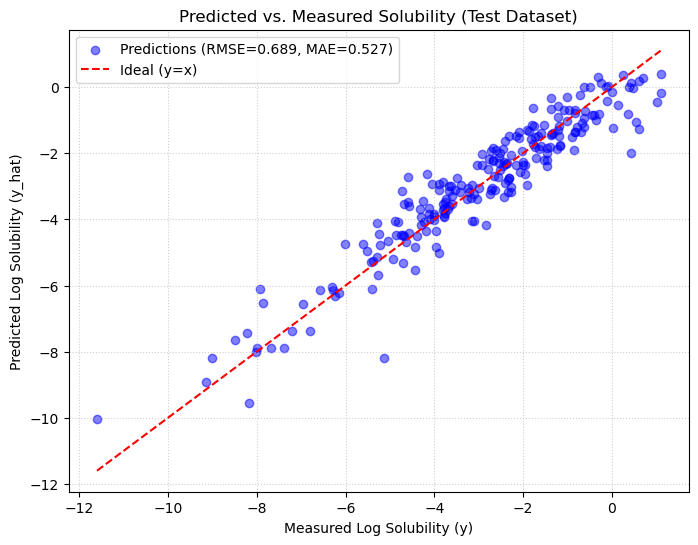

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 画散点图
plt.scatter(all_targets, all_preds, alpha=0.5, color='blue', label=f'Predictions (RMSE={rmse:.3f}, MAE={mae:.3f})')

# 画 45 度理想线
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y=x)')

plt.xlabel('Measured Log Solubility (y)')
plt.ylabel('Predicted Log Solubility (y_hat)')
plt.title('Predicted vs. Measured Solubility (Test Dataset)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()